# Chapter 16: The Prophet
Fit **actual Prophet** to synthetic business activity with weekly seasonality,
a trend change, and a scheduled recurring event. Examine the components,
test whether the event table helps, and choose trend flexibility using only
validation periods. The final test period stays untouched until selection.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0, str(ROOT/'companion/src'))
from forecasting_companion.common import begin, save, plt, np
import pandas as pd
from prophet import Prophet
rng = begin(16)
np.random.seed(16)  # Prophet's interval simulation uses NumPy's global generator.

/Users/jasonkarpeles/Documents/Books/forecasting book/companion/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## The analyst supplies event dates, not event sizes
A synthetic campaign occurs every 45 days. All dates are scheduled in advance;
Prophet must estimate its effect from past occurrences. These are not real
national holidays. Training includes enough repetitions to identify the effect.

In [2]:
t = np.arange(420)
dates = pd.date_range('2024-01-01', periods=len(t), freq='D')
event_days = np.arange(25, 420, 45)
holidays = pd.DataFrame({'holiday': 'scheduled_campaign', 'ds': dates[event_days],
                         'lower_window': 0, 'upper_window': 1})
is_event = np.isin(t, np.r_[event_days, event_days+1])
true_trend = 70+.08*t+.17*np.maximum(t-200, 0)
y = true_trend+8*np.sin(2*np.pi*t/7)+22*is_event+rng.normal(0, 2.4, len(t))
data = pd.DataFrame({'ds': dates, 'y': y})
def fit_prophet(stop, prior=.05, include_events=True, uncertainty=0):
    model = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False,
                    holidays=holidays if include_events else None,
                    changepoint_prior_scale=prior, changepoint_range=.9,
                    uncertainty_samples=uncertainty)
    model.fit(data.iloc[:stop], seed=16)
    return model

## Validate flexibility on earlier origins
Larger changepoint prior scales allow a more flexible trend. Compare three
choices at two earlier origins; freeze the selected choice before forecasting
the final 45 days. Event dates may extend into the future because the calendar
is known, but future outcomes never enter fitting or selection.

16:58:00 - cmdstanpy - INFO - Chain [1] start processing


16:58:00 - cmdstanpy - INFO - Chain [1] done processing


16:58:00 - cmdstanpy - INFO - Chain [1] start processing


16:58:00 - cmdstanpy - INFO - Chain [1] done processing


16:58:00 - cmdstanpy - INFO - Chain [1] start processing


...

16:58:00 - cmdstanpy - INFO - Chain [1] start processing


16:58:00 - cmdstanpy - INFO - Chain [1] done processing


16:58:00 - cmdstanpy - INFO - Chain [1] start processing


16:58:00 - cmdstanpy - INFO - Chain [1] done processing


origin     285     330
prior                 
0.001   10.942  11.567
0.050    2.041   1.868
0.500    2.358   1.937
Chosen on validation only: 0.05


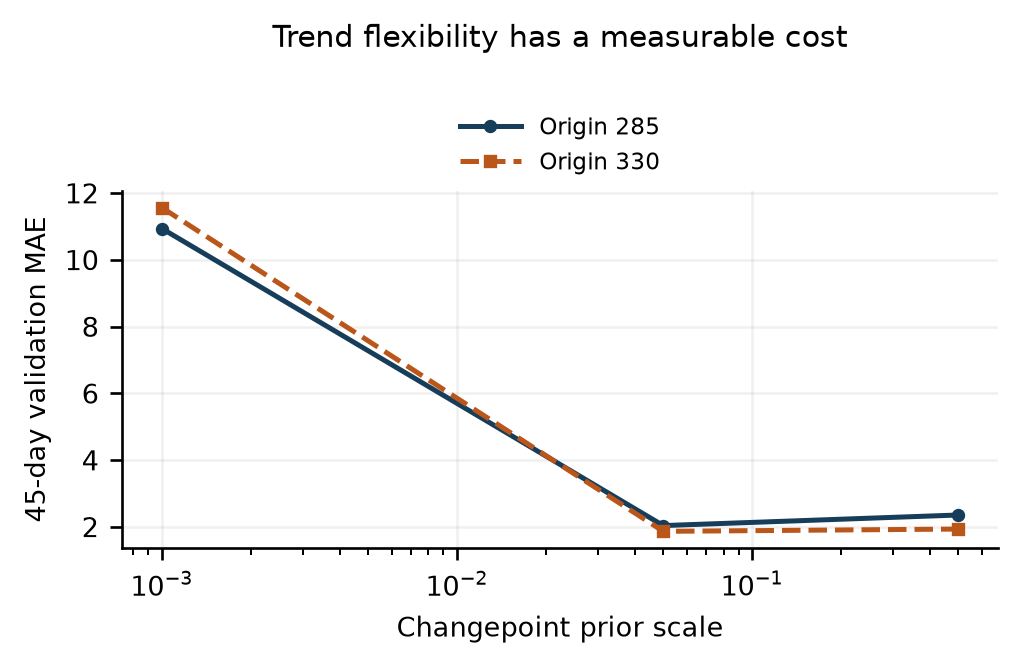

In [3]:
origins, priors = [285,330], [.001, .05, .5]
records = []
for prior in priors:
    for origin in origins:
        fitted = fit_prophet(origin, prior)
        pred = fitted.predict(data[['ds']].iloc[origin:origin+45])
        error = np.mean(abs(data.y.iloc[origin:origin+45].to_numpy()-pred.yhat.to_numpy()))
        records.append(dict(prior=prior, origin=origin, mae=error))
validation = pd.DataFrame(records)
chosen = float(validation.groupby('prior').mae.mean().idxmin())
assert max(origins)+45 <= 375
print(validation.pivot(index='prior', columns='origin', values='mae').round(3).to_string())
print('Chosen on validation only:', chosen)
fig, ax = plt.subplots()
for origin in origins:
    part = validation[validation.origin == origin]
    ax.plot(part.prior, part.mae, marker='o', label=f'Origin {origin}')
ax.set(xscale='log', xlabel='Changepoint prior scale', ylabel='45-day validation MAE', title='Trend flexibility has a measurable cost')
ax.legend(fontsize=6)
save(16, 1, 'Prophet changepoint sensitivity',
     'Actual Prophet fits on synthetic activity, evaluated at two chronological validation origins. Smaller prior scales constrain trend changes more strongly; the final 45 days are not used for selection.',
     'Section Four: The Full Methodology', fig)

## Inspect what the model learned
Prophet returns trend, weekly seasonality, and holiday contributions in units
of the response. With additive mode their sum equals yhat. This is a useful
audit: an implausible component can reveal a calendar or specification error.

16:58:01 - cmdstanpy - INFO - Chain [1] start processing


16:58:01 - cmdstanpy - INFO - Chain [1] done processing


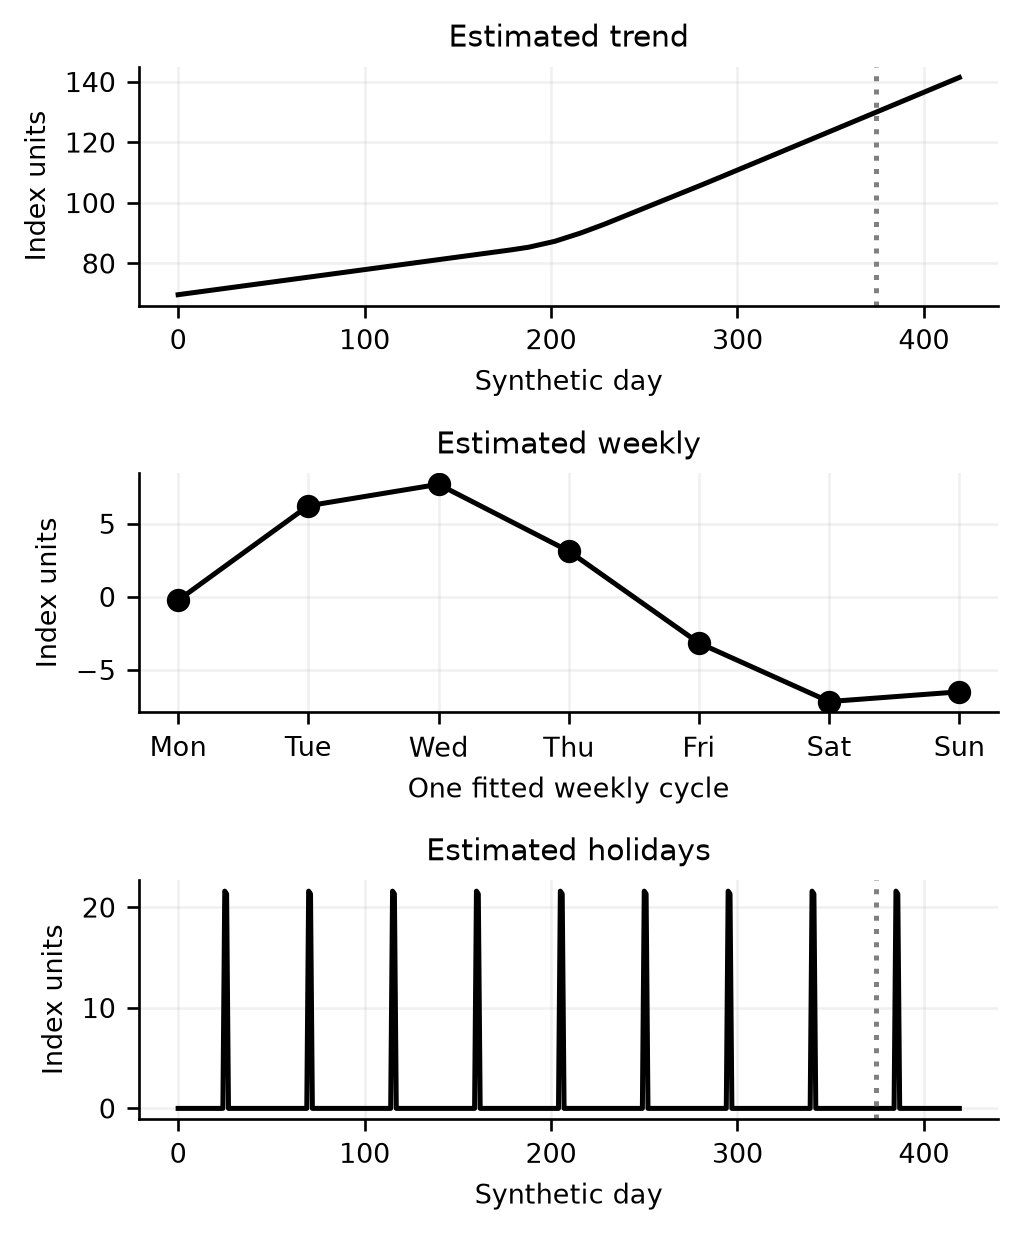

In [4]:
model = fit_prophet(375, chosen, uncertainty=300)
forecast = model.predict(data[['ds']])
assert np.allclose(forecast.yhat, forecast.trend+forecast.weekly+forecast.holidays)
fig, axes = plt.subplots(3, 1, figsize=(4.3, 5.2))
for ax, name in zip(axes, ['trend', 'weekly', 'holidays']):
    if name == 'weekly':
        ax.plot(np.arange(7), forecast[name].iloc[:7], 'o-', color='black')
        ax.set_xticks(np.arange(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
        ax.set_xlabel('One fitted weekly cycle')
    else:
        ax.plot(t, forecast[name], color='black')
        ax.axvline(374.5, color='gray', linestyle=':')
        ax.set_xlabel('Synthetic day')
    ax.set_ylabel('Index units')
    ax.set_title(f'Estimated {name}',fontsize=9)
save(16, 2, 'Prophet component audit',
     'Actual fitted Prophet components. The middle panel shows one weekly cycle, avoiding hundreds of compressed oscillations. Trend and campaign panels use the full synthetic timeline; their dotted lines separate training from final test. Corresponding component values add to the point forecast.',
     'Section Two: What Prophet Got Right', fig)

## Does the calendar improve a held-out forecast?
Tune both model families separately on the same earlier validation origins,
then compare once on the final holdout. This gives the no-calendar alternative
its own chance to choose appropriate flexibility.
Prophet intervals are model-based: calibration must be measured, not assumed.

16:58:01 - cmdstanpy - INFO - Chain [1] start processing


16:58:01 - cmdstanpy - INFO - Chain [1] done processing


16:58:01 - cmdstanpy - INFO - Chain [1] start processing


16:58:01 - cmdstanpy - INFO - Chain [1] done processing


16:58:01 - cmdstanpy - INFO - Chain [1] start processing


...

16:58:01 - cmdstanpy - INFO - Chain [1] start processing


16:58:01 - cmdstanpy - INFO - Chain [1] done processing


16:58:01 - cmdstanpy - INFO - Chain [1] start processing


16:58:01 - cmdstanpy - INFO - Chain [1] done processing


Final MAE with events: 1.75; without: 2.64; nominal 80% coverage: 0.822


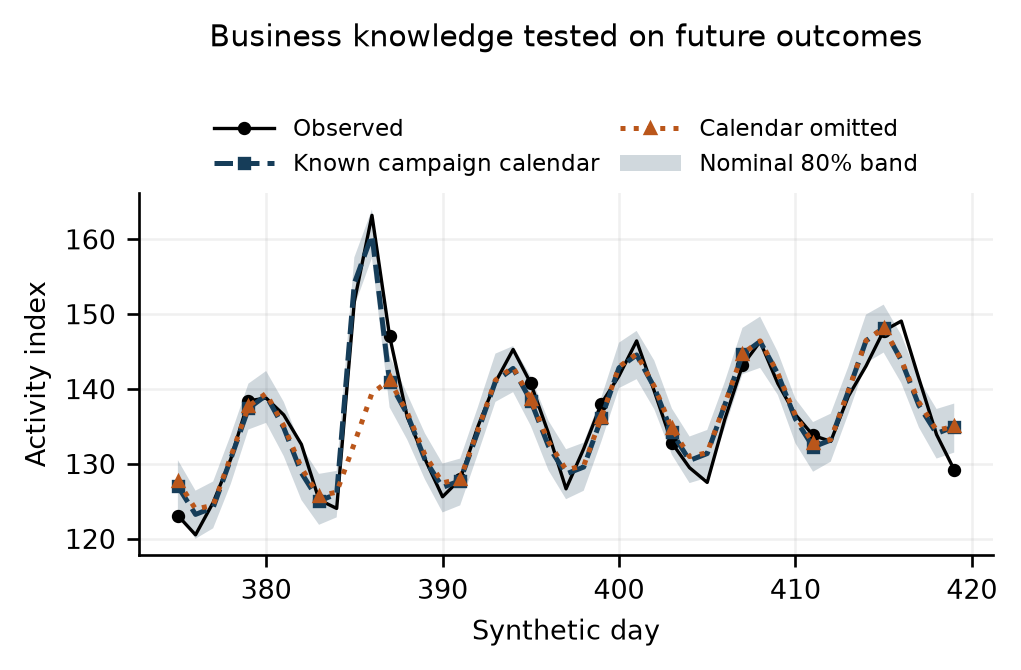

In [5]:
no_event_validation=[]
for prior in priors:
    losses=[]
    for origin in origins:
        alternative=fit_prophet(origin,prior,include_events=False)
        predicted=alternative.predict(data[['ds']].iloc[origin:origin+45])
        losses.append(float(np.mean(abs(data.y.iloc[origin:origin+45].to_numpy()-predicted.yhat.to_numpy()))))
    no_event_validation.append(np.mean(losses))
chosen_no_events=float(priors[int(np.argmin(no_event_validation))])
no_events = fit_prophet(375, chosen_no_events, include_events=False)
no_event_pred = no_events.predict(data[['ds']].iloc[375:])
test_pred = forecast.iloc[375:]
truth = data.y.iloc[375:].to_numpy()
mae_with = np.mean(abs(truth-test_pred.yhat.to_numpy()))
mae_without = np.mean(abs(truth-no_event_pred.yhat.to_numpy()))
coverage = np.mean((truth >= test_pred.yhat_lower) & (truth <= test_pred.yhat_upper))
print(f'Final MAE with events: {mae_with:.2f}; without: {mae_without:.2f}; nominal 80% coverage: {coverage:.3f}')
fig, ax = plt.subplots()
ax.plot(t[375:], truth, color='black', label='Observed', linewidth=1)
ax.plot(t[375:], test_pred.yhat, label='Known campaign calendar')
ax.plot(t[375:], no_event_pred.yhat, label='Calendar omitted', linestyle='--')
ax.fill_between(t[375:], test_pred.yhat_lower, test_pred.yhat_upper, alpha=.2, label='Nominal 80% band')
ax.set(xlabel='Synthetic day', ylabel='Activity index', title='Business knowledge tested on future outcomes')
ax.legend(fontsize=6)
save(16, 3, 'Validate the event calendar',
     'Final 45-day synthetic holdout with an actual Prophet holiday component versus its omission, after separately selecting each model’s flexibility on earlier folds. MAP-based uncertainty is not a calibration guarantee.',
     'Section Five: The Distribution of Responsibility', fig)

## Limitations and exercise
This example was generated with the same additive structure Prophet assumes.
Good performance therefore does not establish superiority on real series.
MAP fitting does not propagate full posterior uncertainty in seasonality;
correlated residuals and unannounced structural changes can defeat the bands.
Exercise: delay the final campaign by a week without updating the calendar.
Score campaign and non-campaign dates separately. What monitoring rule would
detect stale business knowledge before the next forecast is issued?

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below connect the controlled figures to a complete applied input/output workflow.

# Chapter 16 workshop: from lesson to decision

## Explain the mechanism

Prophet makes analyst-supplied structure explicit: trend changes, seasonal cycles and calendar events. The analyst is responsible for whether that structure will remain true. Flexible trend can absorb patterns that should have another explanation.

## Work through the arithmetic

In additive mode, trend 100 plus weekly effect -5 and event effect +20 gives yhat=115. If the event moves but the calendar does not, the model may predict 115 on the wrong day. A perfect component-sum identity checks implementation, not timing accuracy.

Treat this hand calculation as a mechanism check. Compare its units and assumptions with the business target before using the executable adapter below.

## Adapt the lesson to reader data

Replace the data DataFrame with ds,y mapped from reader columns. Replace the synthetic recurring campaign calendar with actual known-at-origin events, not an outcome-selected list of high-sales dates. Keep validation and final-test boundaries intact.

Keep the controlled example as a reproducible teaching case. Work in a copy when replacing its data; retain raw input, a cleaned table and an explanation of exclusions. Real data need a named source, extraction date, usable-as-of date and units. If an actual is revised later, preserve the vintage available when the forecast would have been issued. Never silently label synthetic generator output as an external dataset.

For this chapter, settle these questions before fitting: Which calendar events were known at the origin? Is their effect repeated in history? What trend flexibility is plausible? Which future regressors are actually supplied?

## Interpret the actual lesson outputs

The source runs actual Prophet, chooses flexibility at two earlier origins, and evaluates the final 45 days after selection. Its calendar ablation holds the selected prior fixed, so it isolates calendar omission at that setting rather than separately optimizing both architectures.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,lower,forecast,upper`.
- `summary.json`: `mode,mode_note,prior,validation,ablation,test_mae,test_coverage,nominal,table_scope,events,regressors` plus method, interpretation, assumptions, not_done and status.

Prophet with the event calendar as holidays and the declared regressors. `mode: auto` chooses multiplicative seasonality when a Box-Cox check on training data calls for a log scale, else additive. The changepoint prior is chosen from `priors` on `origins` earlier blocks; the calendar and the regressors are each ablated on the same blocks so their contribution is measured, not assumed. The untouched holdout is scored once with MAE and the coverage of the nominal 80 percent band. The forecast table is the future when no regressors are needed or exactly `horizon` future regressor rows were supplied, otherwise the holdout, and the summary says which under `table_scope`. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

The [fixture](../data/examples/ch16.csv) and [config](../configs/ch16.json) match the current interface. Run the `apply` command in the [skill entrypoint](../../forecasting-skills/forecasting-ch16-prophet/SKILL.md), using a new empty output folder. Any broader methodology in this workshop requires separately recorded evidence or an explicit extension; successful command execution does not imply those steps happened.

## Decide what the evidence supports

Model components are fitted explanations, not independently observed causal effects. A good additive synthetic result favors that generator. MAP intervals omit some parameter uncertainty and can fail under breaks. Do not select flexibility using the final test.

Without repeated event history, use a stated event scenario or omit unsupported event estimation. If future regressors are unknown, provide conditional forecasts. If Prophet is unavailable, name the missing dependency and use a labeled baseline.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,lower,forecast,upper`; `summary.json` keys: `mode,mode_note,prior,validation,ablation,test_mae,test_coverage,nominal,table_scope,events,regressors` plus method, interpretation, assumptions, not_done and status. Quote the ablation: if removing the calendar barely changes validation MAE, the calendar is decoration and the report should say so.

## Three exercises with worked solutions

### Exercise 1

Trend 80, weekly +4, holiday -10 in additive mode: prediction?

**Worked solution.** 74.

### Exercise 2

The last campaign shifts seven days after a forecast is issued. Was the original calendar necessarily leaked?

**Worked solution.** No; it may simply have become stale. Record the schedule vintage and assess the resulting forecast error.

### Exercise 3

May a future event date be included in Prophet fitting?

**Worked solution.** Yes if genuinely known at the origin; its future outcome value must not enter fitting.

## Business-reader application

Use this request with the skill:

> Use chapter 16 to forecast activity.csv with the actual known event calendar, select trend flexibility on earlier origins and explain components and held-out uncertainty.

Read the returned result as a decision record. Check that the forecast answers your unit and horizon, that its comparison uses information available at the time, and that any recommendation follows from the stated loss or business objective. Ask which missing measurement would most change the conclusion.

## Observed-data transfer exercise

A bundled [observed series](../data/observed/monthly-temperature.csv) and [matching config](../configs/ch16-observed.json) provide a second application after the controlled fixture. Read the [data registry](../data/registry.json) for provenance and transformations. These are historical snapshots, not archived real-time release vintages.

```bash
companion/.venv/bin/python companion/scripts/run.py apply --chapter 16 \
  --input companion/data/observed/monthly-temperature.csv \
  --config companion/configs/ch16-observed.json \
  --output companion/applied-runs/ch16-observed-reader
```

Explain whether fitted seasonality transfers to the last year; this temperature example does not validate business-event effects. Record the actual result of your run. Do not import the controlled example’s winner or interpret a successful numerical execution as evidence of operational accuracy.

## Configure and run the applied case

The input file and JSON below are the only entry-point changes needed to try another
case with the same schema. Keep the original examples for comparison. Supply source
and units in the configuration; resolve missing periods rather than silently filling
unknown observations with zeros. These calculations call the same tested functions
as the `run.py apply` command. A failed validation is a reason to inspect the data,
not to replace it with invented observations.

The default input here is a **seeded synthetic schema example**, separate from any
observed-data application below. Read the summary before interpreting its results.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json
import pandas as pd
import json, os
INPUT_PATH = project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists()) / 'companion/data/examples/ch16.csv'
CONFIG_PATH = project_path.parents[2] / 'configs/ch16.json'
# Input paths are explicit and may be replaced with reader-supplied files.
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(16, workshop_input, workshop_config)
print(json.dumps(clean_json(workshop_summary), indent=2))
print(workshop_table.head(12).to_string(index=False))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', CONFIG_PATH.parents[1])) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch16-workshop-results.csv', index=False)
(workshop_output/'ch16-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

16:58:02 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted


Optimization terminated abnormally. Falling back to Newton.


{
  "method": "Prophet with event calendar and known regressors",
  "interpretation": "Prophet (multiplicative seasonality, changepoint prior 0.5) holdout MAE 2.591, nominal 80% band coverage 58%. Removing events changes validation MAE from 1.861 to 4.464. Table scope: future.",
  "assumptions": [
    "multiplicative seasonality chosen by Box-Cox on training data",
    "Event dates and windows correct and known in advance",
    "Regressors known for the horizon"
  ],
  "not_done": [
    "No regressors supplied",
    "Coverage measured on one holdout only; nominal 80% band is not certified"
  ],
  "status": "passed",
  "mode": "multiplicative",
  "mode_note": {
    "boxcox_lambda": -0.12860938948518857
  },
  "prior": 0.5,
  "validation": {
    "0.001": [
      1.478266271649564,
      2.3109005525480186
    ],
    "0.05": [
      1.335973570501988,
      2.416155365489638
    ],
    "0.5": [
      1.3565863967482628,
      2.3649424076761743
    ]
  },
  "ablation": {
    "full": 1.860

1214

## Apply the same workflow to observed data

This second case uses a bundled public-domain historical dataset documented in
`data/registry.json`. It is a revised snapshot, not an archived real-time vintage.
The earlier time cuts prevent fitting on held-out outcomes; they do not undo
revisions that may have occurred before the snapshot was published. Compare the
actual output below with the controlled case. A method need not win to be useful.
The source, transformation and units are in the configuration and registry.

In [7]:
observed_input = pd.read_csv(CONFIG_PATH.parents[1]/'data/observed/monthly-temperature.csv')
observed_config = json.loads((CONFIG_PATH.parent/'ch16-observed.json').read_text())
observed_table, observed_summary = analyze_chapter(16, observed_input, observed_config)
print('Observed-data source:', observed_config['source'])
print(json.dumps(clean_json(observed_summary), indent=2))
print(observed_table.head(12).to_string(index=False))
observed_table.to_csv(workshop_output/'ch16-observed-results.csv', index=False)
(workshop_output/'ch16-observed-summary.json').write_text(json.dumps(clean_json(observed_summary), indent=2)+'\n')

Observed-data source: Public-domain statsmodels El Niño observations, 1950–2010; historical revised snapshot
{
  "method": "Prophet with event calendar and known regressors",
  "interpretation": "Prophet (multiplicative seasonality, changepoint prior 0.05) holdout MAE 0.7201, nominal 80% band coverage 83%. Removing events changes validation MAE from 0.8709 to 0.8709. Table scope: future.",
  "assumptions": [
    "multiplicative seasonality chosen by Box-Cox on training data",
    "Event dates and windows correct and known in advance",
    "Regressors known for the horizon"
  ],
  "not_done": [
    "No regressors supplied",
    "Coverage measured on one holdout only; nominal 80% band is not certified"
  ],
  "status": "passed",
  "mode": "multiplicative",
  "mode_note": {
    "boxcox_lambda": -0.6648820892653157
  },
  "prior": 0.05,
  "validation": {
    "0.001": [
      1.317099862402573,
      0.4292349799589899
    ],
    "0.05": [
      1.2047888653401786,
      0.5370737253800808


1221

## Read the result as a decision record

Start with the summary’s **interpretation**, then examine its numerical evidence.
Distinguish what was fitted, what was supplied, and what remains unidentified.
The results table is the calculation; it is not permission to act. Explain which
assumption would most change the answer and what new evidence would test it.
For a live forecast, set an outcome date and keep the original result for scoring.

The exercises and worked solutions above test interpretation, calculation, and
adaptation. Re-run a changed assumption and compare the actual output; do not
reuse numbers from the book when your input or horizon changes.